# AAA Member Service Usage Prediction and Travel Segmentation

This notebook prepares a member-level dataset, explores key service usage patterns, builds classification models for roadside assistance usage, and adds a travel-focused cluster analysis for potential AAA business recommendations.


## 1. Setup

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

import pandas as pd
import matplotlib.pyplot as plt

In [8]:
try:
    spark.stop()
except:
    pass

spark = (SparkSession.builder
    .appName("AAA Project Update 2")
    .config("spark.port.maxRetries", "100")
    .config("spark.driver.memory", "16g")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/19 07:31:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/19 07:31:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## 2. Load and clean tables

In [9]:
data_path = "/opt/shared/aaa_data_2026_spring/raw/"
id_col = "acxiom_individual_id"


def clean_strings(df):
    for c, t in df.dtypes:
        if t == "string":
            df = df.withColumn(c, F.lower(F.trim(F.col(c))))
            df = df.withColumn(c, F.when(F.col(c).isNull(), "na").otherwise(F.col(c)))
            df = df.withColumn(c, F.when(F.col(c).isin("null", "n/a", ""), "na").otherwise(F.col(c)))
    return df


def read_table(file_name, id_filter=True):
    df = spark.read.csv(data_path + file_name, header=True, inferSchema=True)
    df = df.toDF(*[c.lower() for c in df.columns])
    df = clean_strings(df).drop_duplicates()
    if id_filter and id_col in df.columns:
        df = df.filter(F.col(id_col).isNotNull())
    return df

In [10]:
branch = read_table("Branch_Tbl.csv")
demo = read_table("Demographic_Tbl.csv")
discounts = read_table("DiscountsRewards_Tbl.csv")
ers = read_table("ERS_Tbl.csv")
insurance = read_table("Insurance_Tbl.csv")
member = read_table("Member_Tbl.csv")
member_trans = read_table("MemberTransactions_Tbl.csv", id_filter=False)
mortgage = read_table("Mortgage_Tbl.csv")
tirewheel = read_table("TireWheel_Tbl.csv")
travel = read_table("Travel_Tbl.csv")
visa_account = read_table("VisaAcct_Tbl.csv")
visa_trans = read_table("VisaTransactions_Tbl.csv", id_filter=False)

In [11]:
w_member = Window.partitionBy(id_col).orderBy(F.col("member_expiration_dt").desc_nulls_last())

active_member_condition = (
    F.col("cancel_dt").isNull() |
    (F.lower(F.col("cancel_dt").cast("string")) == "na")
)

member_anchor = (
    member
    .filter(active_member_condition)
    .withColumn("rn", F.row_number().over(w_member))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

member_anchor.count()

1687045

In [12]:
# Create a join-date field and define a recent-member subset for sensitivity analysis only.
# The final modeling table still uses all active members from member_anchor.
member_anchor = member_anchor.withColumn("join_date", F.to_date(F.col("join_club_dt")))

reference_date = member_anchor.agg(F.max("join_date").alias("max_join_date")).collect()[0]["max_join_date"]

member_recent = member_anchor.filter(
    F.col("join_date") >= F.add_months(F.lit(reference_date), -36)
)

print("Active members:", member_anchor.count())
print("Active members joined in the past three years:", member_recent.count())


Active members: 1687045


Active members joined in the past three years: 481443


In [13]:
tables = [
    ("member_raw", member),
    ("member_anchor_active", member_anchor),
    ("member_recent_3yr", member_recent),
    ("demo", demo),
    ("branch", branch),
    ("discounts", discounts),
    ("ers", ers),
    ("insurance", insurance),
    ("mortgage", mortgage),
    ("tirewheel", tirewheel),
    ("travel", travel),
    ("visa_account", visa_account)
]

row_check = []

for name, df in tables:
    rows = df.count()
    unique_members = df.select(id_col).distinct().count()
    row_check.append((name, rows, unique_members))
    print(name, "rows:", rows, "unique members:", unique_members)

pd.DataFrame(row_check, columns=["table", "rows", "unique_members"])

member_raw rows: 2292965 unique members: 2239499


member_anchor_active rows: 1687045 unique members: 1687045


member_recent_3yr rows: 481443 unique members: 481443


demo rows: 1773019 unique members: 1773019


branch rows: 1021901 unique members: 481334
discounts rows: 752155 unique members: 79681


ers rows: 2404787 unique members: 892166
insurance rows: 52626 unique members: 32660
mortgage rows: 41 unique members: 40
tirewheel rows: 318 unique members: 296
travel rows: 216374 unique members: 92471
visa_account rows: 94202 unique members: 61056


,table,rows,unique_members
0,member_raw,2292965,2239499
1,member_anchor_active,1687045,1687045
2,member_recent_3yr,481443,481443
3,demo,1773019,1773019
4,branch,1021901,481334
5,discounts,752155,79681
6,ers,2404787,892166
7,insurance,52626,32660
8,mortgage,41,40
9,tirewheel,318,296


In [14]:
service_label_map = {
    "used_branch": "Branch purchases",
    "used_discounts": "Discount rewards",
    "used_roadside": "Roadside assistance",
    "used_insurance": "Insurance",
    "used_travel": "Travel",
    "used_visa": "Visa account",
    "used_member_trans": "Member transactions",
    "used_tirewheel": "Tire and wheel",
    "used_mortgage": "Mortgage"
}

feature_label_map = {
    "member_trans_total_dues": "Member transaction total dues",
    "member_trans_count": "Member transaction count",
    "member_tenure_years": "Member tenure years",
    "branch_count": "Branch purchase count",
    "branch_total_sales": "Total branch sales",
    "branch_avg_sales": "Average branch sales",
    "branch_discount_total": "Total branch discount",
    "ers_count": "Roadside assistance count",
    "ers_total_cost": "Total roadside cost",
    "ers_avg_cost": "Average roadside cost",
    "insurance_policy_count": "Insurance policy count",
    "insurance_total_premium": "Total insurance premium",
    "travel_trip_count": "Travel trip count",
    "travel_total_value": "Total travel value",
    "travel_avg_value": "Average travel value",
    "visa_account_count": "Visa account count",
    "discount_count": "Discount count",
    "mortgage_count": "Mortgage count",
    "tirewheel_policy_count": "Tire and wheel policy count",
    "demo_income": "Income band",
    "demo_age": "Age group",
    "demo_gender": "Gender",
    "demo_maritalstatus": "Marital status",
    "demo_homeowner": "Homeowner status",
    "member_category": "Membership category",
    "coverage_level": "Coverage level",
    "renew_method": "Renewal method",
    "member_region": "Member region"
}

def clean_label(x):
    x = str(x)

    if x in service_label_map:
        return service_label_map[x]

    if x in feature_label_map:
        return feature_label_map[x]

    x = x.replace("_ohe", "")
    x = x.replace("_indexed", "")
    x = x.replace("_", " ")

    for old, new in feature_label_map.items():
        old_clean = old.replace("_", " ")
        x = x.replace(old_clean, new)

    x = x.replace("demo ", "")
    x = x.replace("used ", "")
    x = x.strip()

    return x.title()

def clean_category(x):
    if x is None:
        return "Unknown"

    x = str(x).replace("_", " ").strip()

    if x.lower() in ["na", "n/a", "null", "none", ""]:
        return "Unknown"

    return x

## 3. Member-level features

In [ ]:
member_anchor = member_anchor.withColumn(
    "member_tenure_years",
    F.floor(F.months_between(F.col("member_expiration_dt"), F.col("join_club_dt")) / 12)
)

member_anchor = member_anchor.withColumn(
    "member_cancelled_flag",
    F.lit(0)
)

member_features = (member_anchor
    .select(
        id_col,
        "member_ky",
        F.col("mbr_category").alias("member_category"),
        F.col("coverage_level_code").alias("coverage_level"),
        F.col("renew_method_cd").alias("renew_method"),
        F.col("dme_fl").alias("direct_mail_flag"),
        F.col("region").alias("member_region"),
        "join_date",
        "member_tenure_years",
        "member_cancelled_flag"
    )
)

member_features.show(5, truncate=False)

In [16]:
demo_features = (demo
    .withColumn("demo_gender", F.when(F.col("consolidated_demo_gender").isin("n", "u"), "na").otherwise(F.col("consolidated_demo_gender")))
    .withColumn("demo_marital", F.when(F.col("maritalstatus") == "inferred married", "married").otherwise(F.col("maritalstatus")))
    .withColumn("demo_age", F.col("consolidated_demo_age").cast("double"))
    .withColumn("demo_age_group",
        F.when(F.col("demo_age").isNull(), "na")
         .when(F.col("demo_age") < 25, "18-24")
         .when(F.col("demo_age") < 35, "25-34")
         .when(F.col("demo_age") < 45, "35-44")
         .when(F.col("demo_age") < 55, "45-54")
         .when(F.col("demo_age") < 65, "55-64")
         .otherwise("65+")
    )
    .select(
        id_col,
        "demo_age",
        "demo_age_group",
        "demo_gender",
        F.col("education").alias("demo_education"),
        "demo_marital",
        F.col("estimatedhousehold_income").alias("demo_income"),
        F.col("homeownerrenter").alias("demo_home"),
        F.col("presenceofchildren").alias("demo_children"),
        F.col("region").alias("demo_region"),
        F.col("everyday").alias("demo_everyday"),
        F.col("tmobile_flag").alias("demo_tmobile_flag")
    )
    .drop_duplicates([id_col])
)

In [17]:
number_pattern = r"[-+]?[0-9]*\.?[0-9]+"

branch = branch.withColumn(
    "discount_amount_num",
    F.regexp_extract(F.col("commerce_discountamount").cast("string"), number_pattern, 0).cast("double")
)

branch = branch.withColumn(
    "discount_percent_num",
    F.regexp_extract(F.col("commerce_discountpercent").cast("string"), number_pattern, 0).cast("double")
)

branch_features = (branch.groupBy(id_col)
    .agg(
        F.count("*").alias("branch_count"),
        F.countDistinct("sale_complete_date").alias("branch_visit_days"),
        F.countDistinct("commerce_catcode").alias("branch_category_count"),
        F.sum("total_sale_amount").alias("branch_total_sales"),
        F.avg("total_sale_amount").alias("branch_avg_sales"),
        F.sum("sale_price").alias("branch_total_sale_price"),
        F.sum("discount_amount_num").alias("branch_discount_total"),
        F.avg("discount_percent_num").alias("branch_avg_discount_percent"),
        F.max("sale_complete_date").alias("branch_last_date")
    )
    .withColumn("branch_days_since_last", F.datediff(F.current_date(), F.col("branch_last_date")))
)

In [18]:
discounts_features = (discounts.groupBy(id_col)
    .agg(
        F.count("*").alias("discount_count"),
        F.countDistinct("partnername").alias("discount_partner_count"),
        F.sum("transactionamount").alias("discount_total_amount"),
        F.avg("transactionamount").alias("discount_avg_amount"),
        F.max("transactiondate").alias("discount_last_date")
    )
    .withColumn("discount_days_since_last", F.datediff(F.current_date(), F.col("discount_last_date")))
)

In [19]:
ers_features = (ers.groupBy(id_col)
    .agg(
        F.count("*").alias("ers_count"),
        F.countDistinct("prob1_code_description").alias("ers_problem_count"),
        F.sum("totalcost").alias("ers_total_cost"),
        F.avg("totalcost").alias("ers_avg_cost"),
        F.max("sc_dt").alias("ers_last_date")
    )
    .withColumn("ers_days_since_last", F.datediff(F.current_date(), F.col("ers_last_date")))
)

In [20]:
insurance_features = (insurance.groupBy(id_col)
    .agg(
        F.count("*").alias("insurance_policy_count"),
        F.countDistinct("pol_typ_desc").alias("insurance_type_count"),
        F.sum("premium").alias("insurance_total_premium"),
        F.avg("premium").alias("insurance_avg_premium"),
        F.max("premium").alias("insurance_max_premium"),
        F.max("pol_date").alias("insurance_last_date"),
        F.max(F.when(F.col("pol_typ_desc").contains("auto"), 1).otherwise(0)).alias("insurance_auto_flag")
    )
    .withColumn("insurance_days_since_last", F.datediff(F.current_date(), F.col("insurance_last_date")))
)

In [15]:
# Member transaction features are prepared for an exploratory sensitivity check only.
# They are intentionally not joined into final_df and are not used in the classification models.
member_key_map = member_anchor.select("member_ky", id_col).drop_duplicates(["member_ky"])
member_trans_id = (member_trans
    .join(member_key_map, member_trans.member_key == member_key_map.member_ky, "left")
    .filter(F.col(id_col).isNotNull())
)

member_trans_features = (member_trans_id.groupBy(id_col)
    .agg(
        F.count("*").alias("member_trans_count"),
        F.countDistinct("transaction_codedecode").alias("member_trans_type_count"),
        F.countDistinct("channel").alias("member_trans_channel_count"),
        F.sum("dues_paid").alias("member_trans_total_dues"),
        F.avg("dues_paid").alias("member_trans_avg_dues"),
        F.sum("rider_dues").alias("member_trans_total_rider_dues"),
        F.max("transaction_date").alias("member_trans_last_date")
    )
    .withColumn("member_trans_days_since_last", F.datediff(F.current_date(), F.col("member_trans_last_date")))
)


In [22]:
mortgage_features = (mortgage.groupBy(id_col)
    .agg(
        F.count("*").alias("mortgage_count"),
        F.sum("brokerfee").alias("mortgage_total_broker_fee"),
        F.avg("brokerfee").alias("mortgage_avg_broker_fee"),
        F.sum("discountpoints").alias("mortgage_total_discount_points"),
        F.sum("closingcredit").alias("mortgage_total_closing_credit"),
        F.max("closingdate").alias("mortgage_last_date")
    )
    .withColumn("mortgage_days_since_last", F.datediff(F.current_date(), F.col("mortgage_last_date")))
)

In [23]:
tirewheel_features = (tirewheel.groupBy(id_col)
    .agg(
        F.count("*").alias("tirewheel_policy_count"),
        F.sum("policytotalcost").alias("tirewheel_total_cost"),
        F.avg("policytotalcost").alias("tirewheel_avg_cost"),
        F.avg("termmonths").alias("tirewheel_avg_term_months"),
        F.max("policyeffectivedate").alias("tirewheel_last_effective_date")
    )
    .withColumn("tirewheel_days_since_last", F.datediff(F.current_date(), F.col("tirewheel_last_effective_date")))
)

In [24]:
travel_features = (travel.groupBy(id_col)
    .agg(
        F.countDistinct("pnrlocator").alias("travel_trip_count"),
        F.countDistinct("traveltypedescription").alias("travel_type_count"),
        F.sum("tripvalue").alias("travel_total_value"),
        F.avg("tripvalue").alias("travel_avg_value"),
        F.sum("commamount").alias("travel_total_commission"),
        F.max("bookdate").alias("travel_last_book_date"),
        F.max("departdate").alias("travel_last_depart_date"),
        F.max(F.when(F.col("traveltypedescription") == "ship", 1).otherwise(0)).alias("travel_ship_flag")
    )
    .withColumn("travel_days_since_last", F.datediff(F.current_date(), F.col("travel_last_book_date")))
)

In [25]:
visa_account_features = (visa_account.groupBy(id_col)
    .agg(
        F.countDistinct("account_id").alias("visa_account_count"),
        F.max(F.when(F.col("activation_fl") == "y", 1).otherwise(0)).alias("visa_active_flag"),
        F.max("account_open_dt").alias("visa_last_open_date"),
        F.max("closed_dt").alias("visa_last_closed_date")
    )
)

visa_trans_id = visa_account.select(id_col, "account_id").join(visa_trans, "account_id", "left")

visa_trans_features = (visa_trans_id.groupBy(id_col)
    .agg(
        F.count("transaction_date").alias("visa_transaction_count"),
        F.countDistinct("transaction_desc").alias("visa_transaction_type_count"),
        F.sum("transaction_amt").alias("visa_total_amount"),
        F.avg("transaction_amt").alias("visa_avg_amount"),
        F.max("transaction_date").alias("visa_last_transaction_date")
    )
    .withColumn("visa_days_since_last", F.datediff(F.current_date(), F.col("visa_last_transaction_date")))
)

visa_features = visa_account_features.join(visa_trans_features, id_col, "left")

## 4. Combined member table

In [ ]:
final_df = member_features

for t in [demo_features, branch_features, discounts_features, ers_features, insurance_features,
          mortgage_features, tirewheel_features, travel_features, visa_features]:
    final_df = final_df.join(t, id_col, "left")

final_df = (final_df
    .withColumn("used_branch", (F.coalesce(F.col("branch_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_discounts", (F.coalesce(F.col("discount_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_roadside", (F.coalesce(F.col("ers_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_insurance", (F.coalesce(F.col("insurance_policy_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_mortgage", (F.coalesce(F.col("mortgage_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_tirewheel", (F.coalesce(F.col("tirewheel_policy_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_travel", (F.coalesce(F.col("travel_trip_count"), F.lit(0)) > 0).cast("int"))
    .withColumn("used_visa", (F.coalesce(F.col("visa_account_count"), F.lit(0)) > 0).cast("int"))
)

numeric_cols = [c for c, t in final_df.dtypes if t in ["int", "bigint", "double", "float", "long"] and c != id_col]
string_cols = [c for c, t in final_df.dtypes if t == "string"]

final_df = final_df.fillna(0, subset=numeric_cols)
final_df = final_df.fillna("na", subset=string_cols)

final_df.select(F.count("*").alias("rows"), F.countDistinct(id_col).alias("unique_members")).show()
final_df.groupBy(id_col).count().orderBy(F.desc("count")).show(5)


In [21]:
service_cols = [
    "used_branch", "used_discounts", "used_roadside", "used_insurance",
    "used_travel", "used_visa", "used_tirewheel", "used_mortgage"
]

feature_summary = []

for c in service_cols:
    members_using_service = final_df.filter(F.col(c) == 1).count()
    feature_summary.append((clean_label(c), members_using_service))

pd.DataFrame(feature_summary, columns=["Service", "Members using service"])

,Service,Members using service
0,Branch purchases,407948
1,Discount rewards,63378
2,Roadside assistance,721588
3,Insurance,25746
4,Travel,78536
5,Visa account,52126
6,Tire and wheel,249
7,Mortgage,38


## 5. Exploratory Analysis

This section starts with simple exploratory patterns before model building. The goal is to show what the data suggests at a high level, then use those patterns to justify the modeling direction.

The final model uses all active members. The recent-member and member-transaction checks below are exploratory sensitivity checks only.


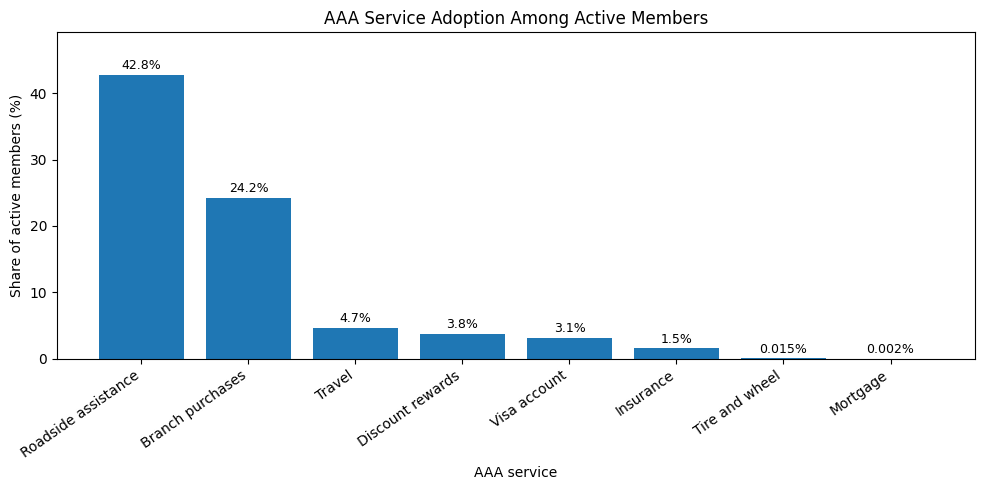

In [22]:
adoption = final_df.agg(*[F.avg(c).alias(c) for c in service_cols]).toPandas().T.reset_index()
adoption.columns = ["service", "usage_rate"]

adoption["service"] = adoption["service"].apply(clean_label)
adoption["usage_percent"] = adoption["usage_rate"] * 100
adoption = adoption.sort_values("usage_percent", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(adoption["service"], adoption["usage_percent"])

plt.xlabel("AAA service")
plt.ylabel("Share of active members (%)")
plt.title("AAA Service Adoption Among Active Members")
plt.xticks(rotation=35, ha="right")

max_value = adoption["usage_percent"].max()

for i, value in enumerate(adoption["usage_percent"]):
    if value < 0.1:
        label = f"{value:.3f}%"
    elif value < 1:
        label = f"{value:.2f}%"
    else:
        label = f"{value:.1f}%"

    plt.text(i, value + max_value * 0.01, label, ha="center", va="bottom", fontsize=9)

plt.ylim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

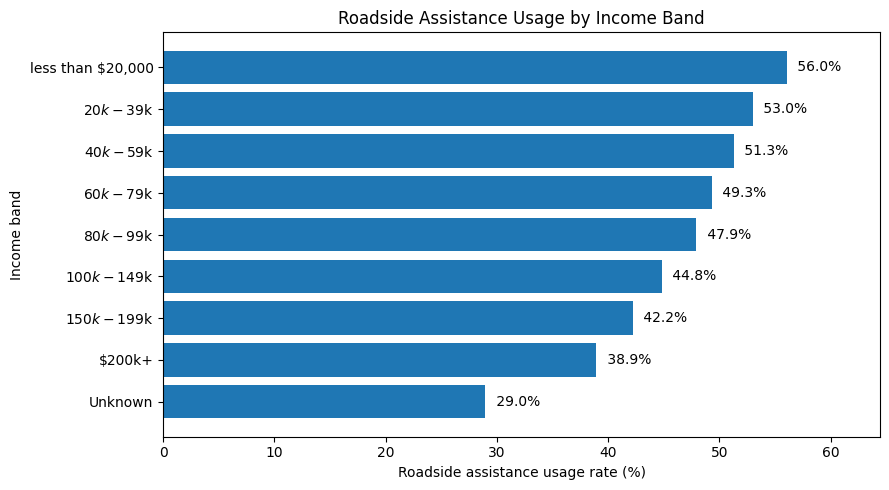

In [23]:
roadside_income = (final_df.groupBy("demo_income")
    .agg(
        F.count("*").alias("members"),
        F.avg("used_roadside").alias("roadside_rate")
    )
    .filter(F.col("members") >= 100)
    .orderBy(F.desc("roadside_rate"))
    .toPandas()
)

roadside_income["income_band"] = roadside_income["demo_income"].apply(clean_category)
roadside_income["roadside_percent"] = roadside_income["roadside_rate"] * 100

plt.figure(figsize=(9, 5))
plt.barh(roadside_income["income_band"], roadside_income["roadside_percent"])
plt.xlabel("Roadside assistance usage rate (%)")
plt.ylabel("Income band")
plt.title("Roadside Assistance Usage by Income Band")
plt.gca().invert_yaxis()

max_value = roadside_income["roadside_percent"].max()

for i, value in enumerate(roadside_income["roadside_percent"]):
    plt.text(value + max_value * 0.01, i, f" {value:.1f}%", va="center")

plt.xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

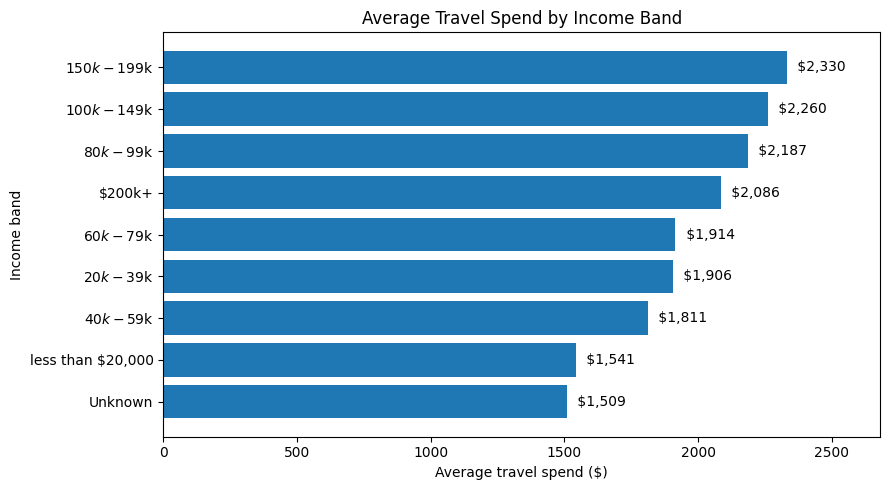

In [24]:
travel_income = (final_df
    .filter(F.col("used_travel") == 1)
    .groupBy("demo_income")
    .agg(
        F.count("*").alias("travel_members"),
        F.avg("travel_total_value").alias("avg_trip_value")
    )
    .filter(F.col("travel_members") >= 50)
    .orderBy(F.desc("avg_trip_value"))
    .toPandas()
)

travel_income["income_band"] = travel_income["demo_income"].apply(clean_category)

plt.figure(figsize=(9, 5))
plt.barh(travel_income["income_band"], travel_income["avg_trip_value"])
plt.xlabel("Average travel spend ($)")
plt.ylabel("Income band")
plt.title("Average Travel Spend by Income Band")
plt.gca().invert_yaxis()

max_value = travel_income["avg_trip_value"].max()

for i, value in enumerate(travel_income["avg_trip_value"]):
    plt.text(value + max_value * 0.01, i, f" ${value:,.0f}", va="center")

plt.xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

### Exploratory sensitivity check: recent members

This check compares the full active-member base with members who joined in the past three years. It is included because recent members may behave differently, but this subset is not used as the final modeling population.


In [25]:
recent_cutoff = F.add_months(F.lit(reference_date), -36)

all_active_summary = (
    final_df
    .agg(
        F.count("*").alias("members"),
        F.avg("used_roadside").alias("roadside_usage_rate"),
        F.avg("used_travel").alias("travel_usage_rate"),
        F.avg("member_tenure_years").alias("avg_member_tenure_years")
    )
    .withColumn("segment", F.lit("All active members"))
    .select("segment", "members", "roadside_usage_rate", "travel_usage_rate", "avg_member_tenure_years")
)

recent_active_summary = (
    final_df
    .filter(F.col("join_date") >= recent_cutoff)
    .agg(
        F.count("*").alias("members"),
        F.avg("used_roadside").alias("roadside_usage_rate"),
        F.avg("used_travel").alias("travel_usage_rate"),
        F.avg("member_tenure_years").alias("avg_member_tenure_years")
    )
    .withColumn("segment", F.lit("Active members joined in past 3 years"))
    .select("segment", "members", "roadside_usage_rate", "travel_usage_rate", "avg_member_tenure_years")
)

sensitivity_summary = all_active_summary.unionByName(recent_active_summary)

sensitivity_pd = sensitivity_summary.toPandas()
sensitivity_pd["roadside_usage_percent"] = sensitivity_pd["roadside_usage_rate"] * 100
sensitivity_pd["travel_usage_percent"] = sensitivity_pd["travel_usage_rate"] * 100

sensitivity_pd[[
    "segment",
    "members",
    "roadside_usage_percent",
    "travel_usage_percent",
    "avg_member_tenure_years"
]]


,segment,members,roadside_usage_percent,travel_usage_percent,avg_member_tenure_years
0,All active members,1687045,42.772303,4.655240,12.367271
1,Active members joined in past 3 years,481443,33.069335,3.212218,1.556055


### Exploratory sensitivity check: member transactions

Member transactions can be highly predictive, but they may also dominate the model and make the results less useful for explaining broader service behavior. For that reason, transaction features are explored here but excluded from the final classification models.


In [26]:
member_trans_exploration = (
    final_df
    .select(id_col, "used_roadside", "used_travel", "member_tenure_years")
    .join(member_trans_features, id_col, "left")
    .withColumn("member_trans_count_filled", F.coalesce(F.col("member_trans_count"), F.lit(0)))
    .withColumn("member_trans_total_dues_filled", F.coalesce(F.col("member_trans_total_dues"), F.lit(0.0)))
    .withColumn("used_member_trans", (F.col("member_trans_count_filled") > 0).cast("int"))
)

member_trans_summary = (
    member_trans_exploration
    .groupBy("used_member_trans")
    .agg(
        F.count("*").alias("members"),
        F.avg("used_roadside").alias("roadside_usage_rate"),
        F.avg("used_travel").alias("travel_usage_rate"),
        F.avg("member_tenure_years").alias("avg_member_tenure_years"),
        F.avg("member_trans_count_filled").alias("avg_member_transactions"),
        F.avg("member_trans_total_dues_filled").alias("avg_member_transaction_dues")
    )
    .orderBy("used_member_trans")
)

member_trans_summary_pd = member_trans_summary.toPandas()
member_trans_summary_pd["member_transaction_group"] = member_trans_summary_pd["used_member_trans"].map({
    0: "No member transaction history",
    1: "Has member transaction history"
})
member_trans_summary_pd["roadside_usage_percent"] = member_trans_summary_pd["roadside_usage_rate"] * 100
member_trans_summary_pd["travel_usage_percent"] = member_trans_summary_pd["travel_usage_rate"] * 100

member_trans_summary_pd[[
    "member_transaction_group",
    "members",
    "roadside_usage_percent",
    "travel_usage_percent",
    "avg_member_tenure_years",
    "avg_member_transactions",
    "avg_member_transaction_dues"
]]


,member_transaction_group,members,roadside_usage_percent,travel_usage_percent,avg_member_tenure_years,avg_member_transactions,avg_member_transaction_dues
0,No member transaction history,13168,13.866950,1.511239,0.869380,0.000000,0.000000
1,Has member transaction history,1673877,42.999695,4.679973,12.457722,2.781339,192.625013


## 6. Model target

In [28]:
model_df = final_df.withColumn("label", F.col("used_roadside").cast("double"))

model_df.groupBy("label").count().orderBy("label").show()

+-----+------+
|label| count|
+-----+------+
|  0.0|965457|
|  1.0|721588|
+-----+------+



## 7. Classification Models

In [3]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

In [29]:
categorical_features = [
    "demo_age_group", "demo_gender", "demo_education", "demo_marital",
    "demo_income", "demo_home", "demo_children", "demo_region",
    "member_category", "coverage_level", "renew_method", "direct_mail_flag"
]

numeric_features = [
    "member_tenure_years",
    "branch_count", "branch_total_sales", "branch_avg_sales", "branch_discount_total",
    "discount_count", "discount_partner_count", "discount_total_amount",
    "insurance_policy_count", "insurance_total_premium", "insurance_auto_flag",
    "mortgage_count", "mortgage_total_broker_fee",
    "tirewheel_policy_count", "tirewheel_total_cost",
    "travel_trip_count", "travel_total_value", "travel_ship_flag",
    "visa_account_count", "visa_active_flag", "visa_transaction_count", "visa_total_amount"
]

selected = ["label"] + categorical_features + numeric_features
model_df = model_df.select(*selected)

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print(train_df.count(), test_df.count())

numeric_features = [c for c in numeric_features if c in model_df.columns]
categorical_features = [c for c in categorical_features if c in model_df.columns]


1348695 338350


In [30]:
def score_model(pred_df, model_name):
    evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    auc = evaluator.evaluate(pred_df)

    tp = pred_df.filter((F.col("label") == 1) & (F.col("prediction") == 1)).count()
    fp = pred_df.filter((F.col("label") == 0) & (F.col("prediction") == 1)).count()
    tn = pred_df.filter((F.col("label") == 0) & (F.col("prediction") == 0)).count()
    fn = pred_df.filter((F.col("label") == 1) & (F.col("prediction") == 0)).count()

    accuracy = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return [(model_name, float(auc), float(accuracy), float(precision), float(recall), float(f1), int(tp), int(fp), int(tn), int(fn))]

In [30]:
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in categorical_features]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe") for c in categorical_features]

lr_inputs = [c + "_ohe" for c in categorical_features] + numeric_features
lr_assembler = VectorAssembler(inputCols=lr_inputs, outputCol="features", handleInvalid="keep")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=25, regParam=0.05)

lr_pipeline = Pipeline(stages=indexers + encoders + [lr_assembler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_pred = lr_model.transform(test_df)

metric_cols = ["model", "auc", "accuracy", "precision", "recall", "f1", "tp", "fp", "tn", "fn"]

pd.DataFrame(
    score_model(lr_pred, "Logistic Regression"),
    columns=metric_cols
)

NameError: name 'score_model' is not defined

### Logistic Regression Coefficient Direction

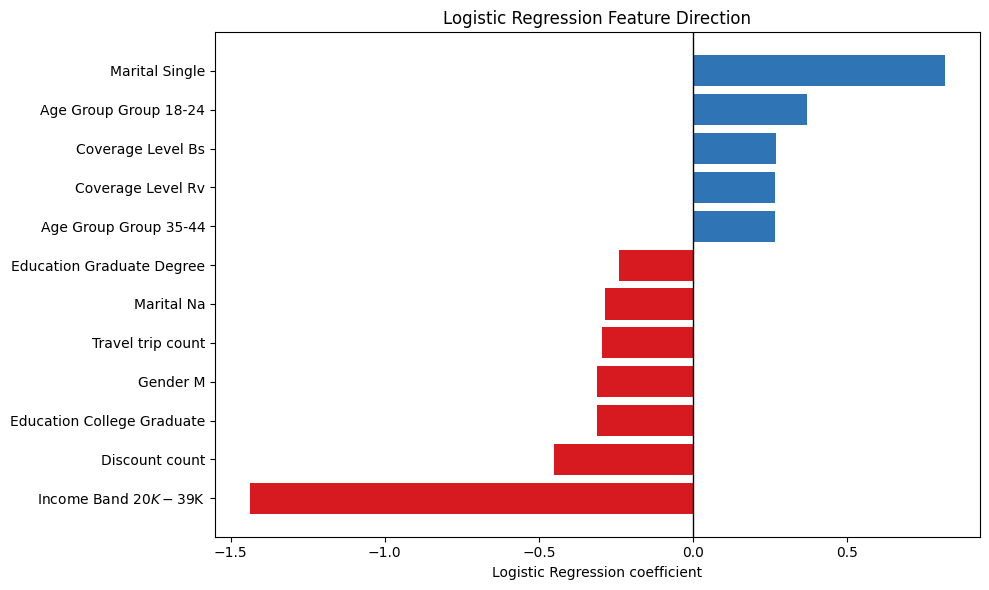

In [32]:
def get_feature_names_from_metadata(df, features_col="features"):
    attrs = df.schema[features_col].metadata["ml_attr"]["attrs"]
    feature_names = []
    for attr_type in attrs:
        feature_names += [x["name"] for x in attrs[attr_type]]
    return feature_names

lr_stage = lr_model.stages[-1]
lr_feature_names = get_feature_names_from_metadata(lr_pred, "features")

lr_direction = pd.DataFrame({
    "feature": lr_feature_names,
    "coefficient": lr_stage.coefficients.toArray()
})

lr_direction["feature_label"] = lr_direction["feature"].apply(clean_label)
lr_direction["direction"] = lr_direction["coefficient"].apply(lambda x: "Positive" if x > 0 else "Negative")

lr_top_direction = lr_direction.reindex(lr_direction["coefficient"].abs().sort_values(ascending=False).index).head(12)
lr_top_direction = lr_top_direction.sort_values("coefficient")

plt.figure(figsize=(10, 6))
colors = ["#D71920" if x < 0 else "#2F75B5" for x in lr_top_direction["coefficient"]]
plt.barh(lr_top_direction["feature_label"], lr_top_direction["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic Regression coefficient")
plt.title("Logistic Regression Feature Direction")
plt.tight_layout()
plt.show()


In [33]:
rf_inputs = [c + "_idx" for c in categorical_features] + numeric_features
rf_assembler = VectorAssembler(inputCols=rf_inputs, outputCol="features", handleInvalid="keep")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=6, seed=42)

rf_pipeline = Pipeline(stages=indexers + [rf_assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df)

pd.DataFrame(
    score_model(rf_pred, "Random Forest"),
    columns=metric_cols
)

,model,auc,accuracy,precision,recall,f1,tp,fp,tn,fn
0,Random Forest,0.627963,0.587885,0.623245,0.097357,0.168407,14119,8535,184792,130904


## 8. Model Refining

In [34]:
rf_tune = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_tune_pipeline = Pipeline(stages=indexers + [rf_assembler, rf_tune])

grid = (ParamGridBuilder()
    .addGrid(rf_tune.numTrees, [30, 60])
    .addGrid(rf_tune.maxDepth, [5, 8])
    .build())

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

tvs = TrainValidationSplit(
    estimator=rf_tune_pipeline,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

tuned_rf_model = tvs.fit(train_df)
tuned_rf_pred = tuned_rf_model.transform(test_df)

pd.DataFrame(
    score_model(tuned_rf_pred, "Tuned Random Forest"),
    columns=metric_cols
)

,model,auc,accuracy,precision,recall,f1,tp,fp,tn,fn
0,Tuned Random Forest,0.634289,0.596882,0.6033,0.173731,0.269775,25195,16567,176760,119828


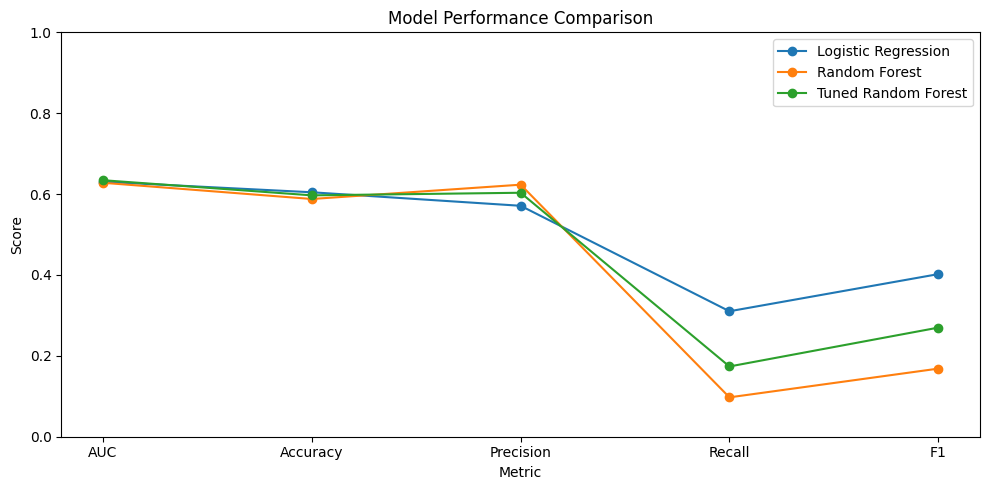

In [35]:
model_results = pd.concat([
    pd.DataFrame(score_model(lr_pred, "Logistic Regression"), columns=metric_cols),
    pd.DataFrame(score_model(rf_pred, "Random Forest"), columns=metric_cols),
    pd.DataFrame(score_model(tuned_rf_pred, "Tuned Random Forest"), columns=metric_cols)
])

model_plot = model_results[["model", "auc", "accuracy", "precision", "recall", "f1"]]

model_plot_long = model_plot.melt(
    id_vars="model",
    value_vars=["auc", "accuracy", "precision", "recall", "f1"],
    var_name="Metric",
    value_name="Score"
)

model_plot_long["Metric"] = model_plot_long["Metric"].replace({
    "auc": "AUC",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1"
})

plt.figure(figsize=(10, 5))

for model_name in model_plot["model"]:
    temp = model_plot_long[model_plot_long["model"] == model_name]
    plt.plot(temp["Metric"], temp["Score"], marker="o", label=model_name)

plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

Logistic Regression Lift Curve


/opt/conda/envs/BigDataEnv/lib/python3.12/site-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):
/opt/conda/envs/BigDataEnv/lib/python3.12/site-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):




Logistic Regression Decile Table


/opt/conda/envs/BigDataEnv/lib/python3.12/site-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):
/opt/conda/envs/BigDataEnv/lib/python3.12/site-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):


average response rate:  0.42861829466528745


Target,Decile,Negatives,Positives,Response_Rate,Lift,Cumulated_Response_Rate,Cumulative_Lift,KS
0,1,13129,20706,0.61,1.42,0.61,1.42,4.3
1,2,15328,18507,0.55,1.28,0.58,1.35,7.0
2,3,16667,17168,0.51,1.19,0.56,1.31,8.9
3,4,17775,16060,0.47,1.10,0.54,1.26,10.0
4,5,18723,15112,0.45,1.05,0.52,1.21,10.4
5,6,19637,14198,0.42,0.98,0.50,1.17,10.2
6,7,20458,13377,0.40,0.93,0.49,1.14,9.4
7,8,21552,12283,0.36,0.84,0.47,1.10,7.9
8,9,22959,10876,0.32,0.75,0.45,1.05,5.4
9,10,27099,6736,0.20,0.47,0.43,1.00,0.0


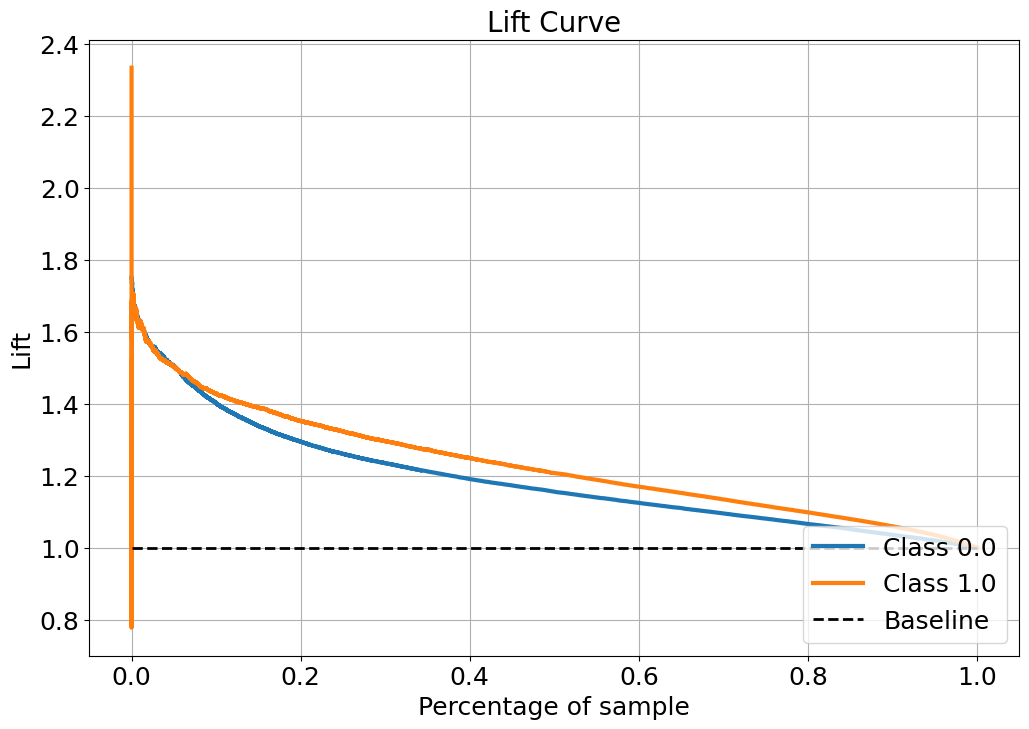

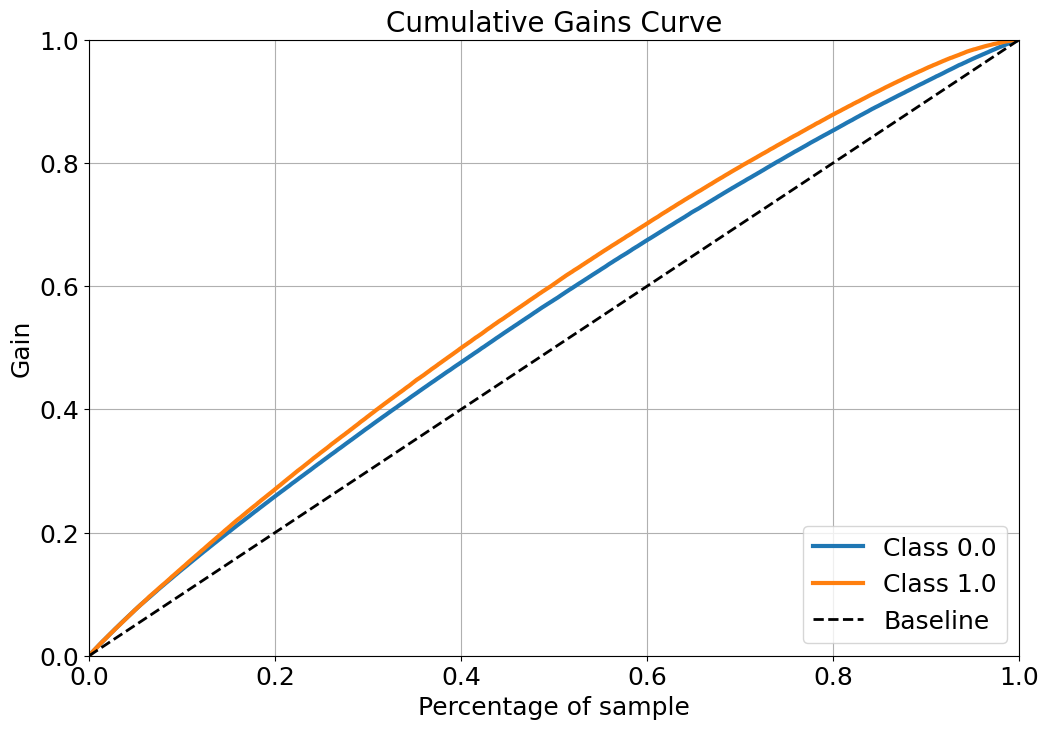

In [33]:
import helper_functions as hf
from pyspark.ml.functions import vector_to_array

hf.to_array = vector_to_array

display_lift_chart = hf.display_lift_chart
display_decile_table = hf.display_decile_table

print("Logistic Regression Lift Curve")
display_lift_chart(lr_pred)

print("Logistic Regression Decile Table")
lr_decile_table = display_decile_table(lr_pred, cardinality=10)
lr_decile_table

## 9. Feature Importance and Interpretation

In [36]:
best_rf = tuned_rf_model.bestModel.stages[-1]
rf_feature_names = rf_inputs

importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": best_rf.featureImportances.toArray()
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
12,member_tenure_years,0.316438
0,demo_age_group_idx,0.121589
1,demo_gender_idx,0.086000
4,demo_income_idx,0.078679
5,demo_home_idx,0.078261
3,demo_marital_idx,0.064693
7,demo_region_idx,0.054321
9,coverage_level_idx,0.045911
6,demo_children_idx,0.040929
13,branch_count,0.020659


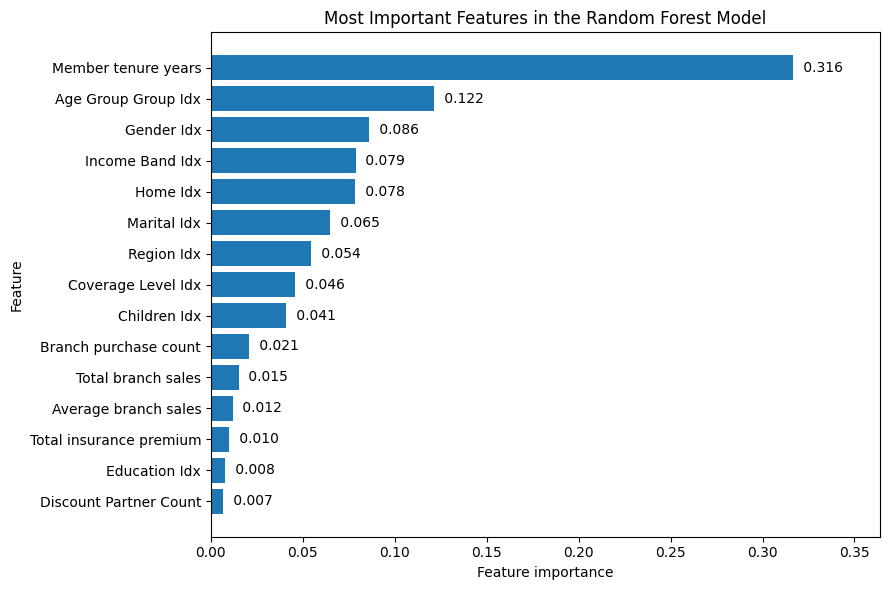

In [37]:
top_importance = importance.head(15).copy()
top_importance["feature_label"] = top_importance["feature"].apply(clean_label)
top_importance = top_importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature_label"], top_importance["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Most Important Features in the Random Forest Model")

max_value = top_importance["importance"].max()

for i, value in enumerate(top_importance["importance"]):
    plt.text(value + max_value * 0.01, i, f" {value:.3f}", va="center")

plt.xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

## 10. Travel-Focused Cluster Analysis

In [38]:

from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

cluster_features = [
    "branch_count",
    "discount_count",
    "ers_count",
    "insurance_policy_count",
    "travel_trip_count",
    "travel_total_value",
    "travel_avg_value",
    "visa_account_count",
    "visa_transaction_count",
    "member_tenure_years"
]

cluster_features = [c for c in cluster_features if c in final_df.columns]

cluster_df = final_df.select(id_col, *cluster_features, "used_travel").fillna(0)

cluster_assembler = VectorAssembler(inputCols=cluster_features, outputCol="cluster_raw_features", handleInvalid="keep")
cluster_scaler = StandardScaler(inputCol="cluster_raw_features", outputCol="cluster_features")

cluster_prepared = cluster_assembler.transform(cluster_df)
cluster_scaled_model = cluster_scaler.fit(cluster_prepared)
cluster_scaled = cluster_scaled_model.transform(cluster_prepared)

silhouette_rows = []
for k in [3, 4, 5]:
    kmeans = KMeans(featuresCol="cluster_features", predictionCol="cluster", k=k, seed=42)
    model = kmeans.fit(cluster_scaled)
    predictions = model.transform(cluster_scaled)
    evaluator = ClusteringEvaluator(featuresCol="cluster_features", predictionCol="cluster")
    score = evaluator.evaluate(predictions)
    silhouette_rows.append((k, score))

silhouette_pd = pd.DataFrame(silhouette_rows, columns=["k", "silhouette_score"])
silhouette_pd


,k,silhouette_score
0,3,0.474580
1,4,0.451570
2,5,0.456115


In [39]:
best_k = int(silhouette_pd.sort_values("silhouette_score", ascending=False).iloc[0]["k"])

kmeans = KMeans(
    featuresCol="cluster_features",
    predictionCol="travel_cluster",
    k=best_k,
    seed=42
)

cluster_model = kmeans.fit(cluster_scaled)
cluster_predictions = cluster_model.transform(cluster_scaled)

cluster_assignments = cluster_predictions.select(
    id_col,
    "travel_cluster"
).dropDuplicates([id_col])

travel_cluster_input = final_df.select(
    id_col,
    "demo_income",
    "demo_age_group",
    "travel_total_value",
    "travel_trip_count",
    "used_travel"
)

cluster_summary = (
    cluster_assignments
    .join(travel_cluster_input, id_col, "left")
    .groupBy("travel_cluster")
    .agg(
        F.count("*").alias("members"),
        F.avg("used_travel").alias("travel_usage_rate"),
        F.avg("travel_total_value").alias("avg_travel_value"),
        F.avg("travel_trip_count").alias("avg_travel_trips")
    )
    .orderBy("travel_cluster")
)

cluster_summary_pd = cluster_summary.toPandas()
cluster_summary_pd["travel_usage_percent"] = cluster_summary_pd["travel_usage_rate"] * 100

cluster_summary_pd

,travel_cluster,members,travel_usage_rate,avg_travel_value,avg_travel_trips,travel_usage_percent
0,0,1219343,0.029940,18.529146,0.042614,2.993989
1,1,441974,0.090152,317.514342,0.209763,9.015236
2,2,25728,0.084888,172.350126,0.165734,8.488806


In [42]:
cluster_name_map = {
    0: "Low Travel Engagement Members",
    1: "High-Value Travel Opportunity Members",
    2: "Selective Travel Members"
}

cluster_summary_pd["cluster_name"] = cluster_summary_pd["travel_cluster"].map(cluster_name_map)

cluster_summary_pd[[
    "travel_cluster",
    "cluster_name",
    "members",
    "travel_usage_percent",
    "avg_travel_value",
    "avg_travel_trips"
]]

,travel_cluster,cluster_name,members,travel_usage_percent,avg_travel_value,avg_travel_trips
0,0,Low Travel Engagement Members,1219343,2.993989,18.529146,0.042614
1,1,High-Value Travel Opportunity Members,441974,9.015236,317.514342,0.209763
2,2,Selective Travel Members,25728,8.488806,172.350126,0.165734


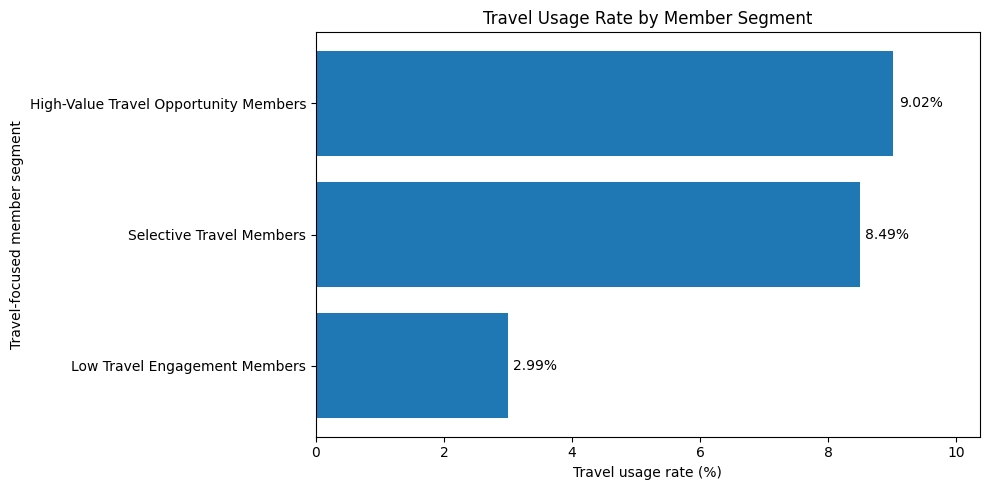

In [46]:
cluster_summary_pd = cluster_summary_pd.sort_values("travel_usage_percent")

plt.figure(figsize=(10, 5))

plt.barh(
    cluster_summary_pd["cluster_name"],
    cluster_summary_pd["travel_usage_percent"]
)

plt.xlabel("Travel usage rate (%)")
plt.ylabel("Travel-focused member segment")
plt.title("Travel Usage Rate by Member Segment")

max_value = cluster_summary_pd["travel_usage_percent"].max()

for i, value in enumerate(cluster_summary_pd["travel_usage_percent"]):
    plt.text(
        value + max_value * 0.01,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.xlim(0, max_value * 1.15)
plt.tight_layout()
plt.show()